# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor






## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv('../data/checker_regression.csv')
df.head()

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN


In [3]:
#filling missing values
df = df.fillna(0)

In [4]:
# split features
X = df.drop(['AVG(diff)', 'uid'], axis=1)
y = df['AVG(diff)']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21
)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [5]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    
    rmses = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        print(f"train - {train_rmse} | test - {test_rmse}")
        
        rmses.append(test_rmse)
    
    print(f"\nAverage RMSE on crossval is {np.mean(rmses)}")

In [6]:
crossval(10, X, y, LinearRegression())

train - 42.27291015233797 | test - 70.43979397280242
train - 47.45726648237968 | test - 30.65739401435404
train - 47.77854388604299 | test - 27.137319378269105
train - 46.2441901620785 | test - 44.123072052096376
train - 46.39355004742244 | test - 42.420391728163665
train - 47.71541914802497 | test - 28.273391654514054
train - 46.308918660456506 | test - 45.67313727400561
train - 47.81194647242181 | test - 20.57247658092342
train - 44.12915324532897 | test - 63.14957718941947
train - 42.350893141368886 | test - 74.15893330081012

Average RMSE on crossval is 44.66054871453583


In [7]:
crossval(10, X, y, DecisionTreeRegressor(random_state=21))

train - 0.0 | test - 71.88489835223467
train - 0.0 | test - 25.24371208835975
train - 0.0 | test - 0.0
train - 0.0 | test - 20.293964620053917
train - 0.0 | test - 72.20506003352149
train - 0.0 | test - 28.991378028648448
train - 0.0 | test - 7.0364255643204405
train - 0.0 | test - 8.126236169698386
train - 0.0 | test - 86.63649383194165
train - 0.0 | test - 65.93049851867218

Average RMSE on crossval is 38.634866720745094


In [8]:
crossval(10, X, y, RandomForestRegressor(random_state=21))

train - 12.777661106062592 | test - 55.21884918830304
train - 14.944676960459738 | test - 14.136950174002187
train - 15.145373082774338 | test - 0.0
train - 14.781775951331486 | test - 26.925919120802543
train - 12.998387321887547 | test - 52.704000228872594
train - 15.162144682092565 | test - 32.380540830875574
train - 16.39491297753858 | test - 14.53373200141274
train - 14.98799883276986 | test - 22.20654668271111
train - 14.09532647051205 | test - 69.45674467575043
train - 15.002690750328759 | test - 42.562647313312866

Average RMSE on crossval is 33.01259302160431


Random Forest shows the lowest RMSE (~33.01), outperforming Decision Tree (~38.63) and Linear Regression (~44.66). Therefore, Random Forest is the best model.

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

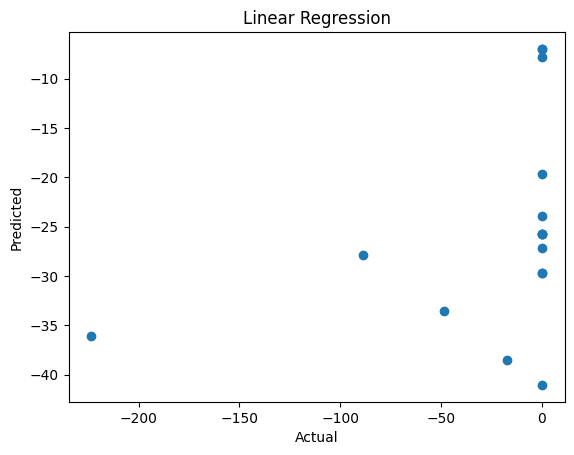

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

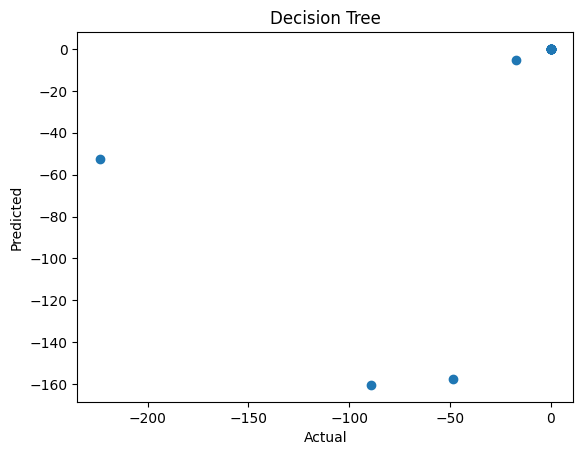

In [10]:
model = DecisionTreeRegressor(random_state=21)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.title("Decision Tree")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

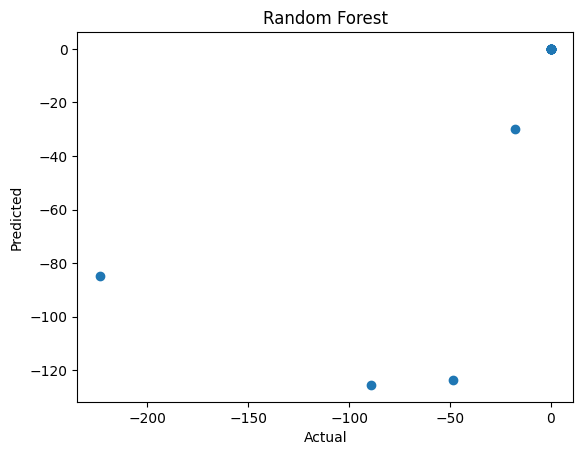

In [11]:
model = RandomForestRegressor(random_state=21)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

- Answering the question: In the ideal case(), all points would lie on a straight diagonal line (y = x), meaning predictions exactly match actual values.